# SAR → EO — Exploratory Data Analysis

Dataset: the local `v_2/` terrain subset — the same **`yuuIind/SAR2Optical` protocol (16,000 SEN-12 pairs, 4 terrains)** the provided survey (Wang et al., 2026) benchmarks in its Table 2, so our numbers will be directly comparable to published baselines.

**Setup**

In [1]:
import json, sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
sys.path.insert(0, '..')
from src.data.dataset import index_dataset, build_splits, TERRAINS

STATS = json.loads(Path('../outputs/eda/eda_stats.json').read_text())
samples = index_dataset('../v_2')
print(f'{len(samples):,} paired samples across {len(TERRAINS)} terrains')

16,000 paired samples across 4 terrains


## 1. Inventory: patches, scenes, seasons

How many pairs, and crucially how many *independent scenes* do they come from?

,terrain,pairs,scenes,largest_scene_%,seasons
0,agri,4000,6,34.3,"summer:1370, fall:2630"
1,barrenland,4000,7,27.0,fall:4000
2,grassland,4000,6,31.2,fall:4000
3,urban,4000,13,19.9,fall:4000


TOTAL scenes across all 16k patches: 32


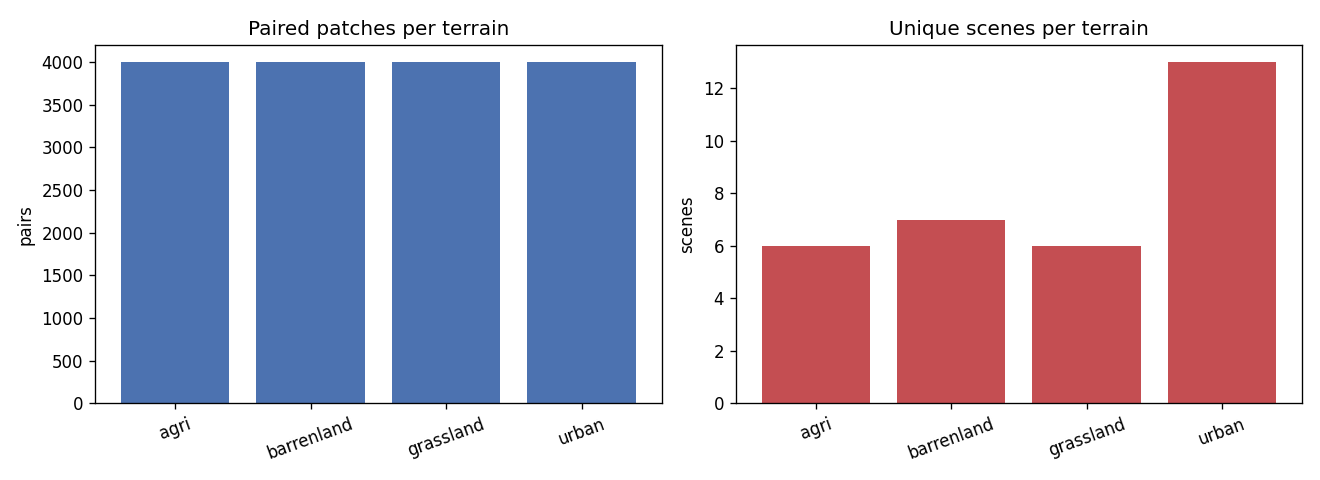

In [2]:
from IPython.display import Image as IPyImage, display
import pandas as pd
rows = []
for t in TERRAINS:
    v = STATS['inventory'][t]
    rows.append({'terrain': t, 'pairs': v['pairs'], 'scenes': v['n_scenes'],
                 'largest_scene_%': round(100*v['largest_scene_frac'],1),
                 'seasons': ', '.join(f'{k}:{n}' for k,n in v['seasons'].items())})
df = pd.DataFrame(rows); display(df)
print('TOTAL scenes across all 16k patches:', STATS['n_scenes_total'])
display(IPyImage('../outputs/eda/01_inventory.png'))

**Insight (measured).** All 16,000 patches come from only **32 unique scenes** (agri 6, barrenland 7, grassland 6, urban 13). Scene sizes are highly imbalanced — from 18 to 1370 patches (median 346), and a single scene can be 34% of a terrain. → This is the single most consequential fact for the split design (Section 5): patches within a scene share acquisition geometry, season, calibration and land cover, so a **random split leaks** scene distribution between train and test. We confirm this quantitatively in Section 3.

## 2. Modality statistics: dynamic range, speckle, colour

SAR and optical differ in dynamic range, noise and statistics — the brief asks us to state how we normalise each (§2.2). We measure both.

,terrain,SAR_mean,SAR_std,SAR_p1,SAR_p99,speckle_CoV,EO_mean_RGB
0,agri,130.0,51.9,4,252,0.265,"[76, 75, 72]"
1,barrenland,123.2,54.9,0,255,0.283,"[109, 98, 93]"
2,grassland,124.1,46.6,3,245,0.234,"[56, 72, 46]"
3,urban,157.0,49.6,20,255,0.201,"[71, 70, 66]"


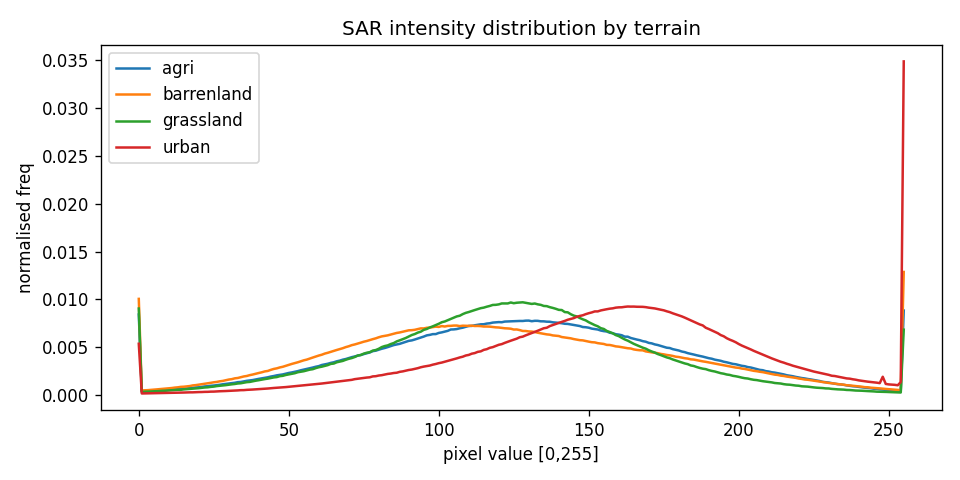

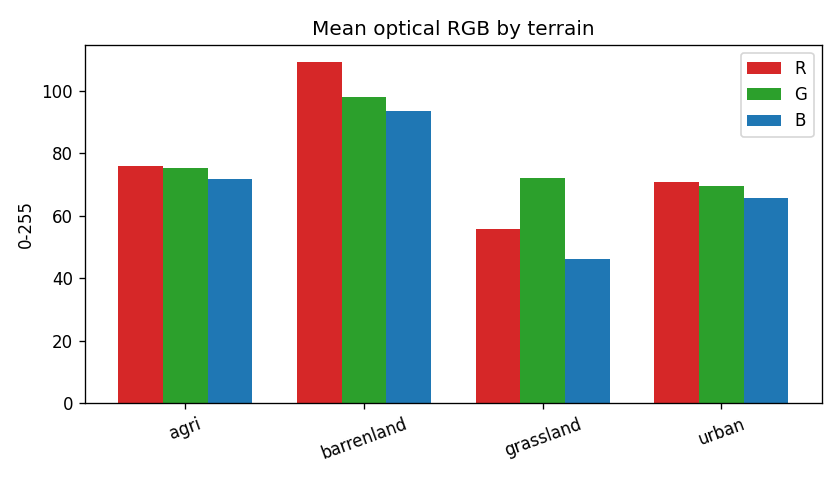

In [3]:
rows = []
for t in TERRAINS:
    s = STATS['sar_stats'][t]; e = STATS['eo_stats'][t]
    rows.append({'terrain': t, 'SAR_mean': round(s['mean'],1), 'SAR_std': round(s['std'],1),
                 'SAR_p1': round(s['p1']), 'SAR_p99': round(s['p99']),
                 'speckle_CoV': round(s['speckle_cov_mean'],3),
                 'EO_mean_RGB': [round(x) for x in e['mean_rgb']]})
display(pd.DataFrame(rows))
display(IPyImage('../outputs/eda/02_sar_histograms.png'))
display(IPyImage('../outputs/eda/03_eo_mean_color.png'))

**Insight (measured).**
- **SAR dynamic range & speckle.** SAR is single-channel uint8 already spanning ~[0,255]; per-terrain p1–p99 covers most of the range (e.g. barrenland 0–255). Mean local coefficient-of-variation (a speckle proxy) is **0.283** (highest, barrenland) down to 0.201 — i.e. ~20–28% local intensity variation even within homogeneous regions, confirming strong multiplicative speckle. We therefore do **not** despeckle aggressively (it destroys signal) and treat speckle as inherent.
- **Backscatter differs by land cover.** `urban` is the brightest SAR (mean 157.0) — consistent with strong double-bounce from buildings — while `barrenland` is darker (mean 123.2). So SAR intensity carries *structural/material* cues but, as Section 3 shows, not colour.
- **Optical colour is terrain-specific.** Vegetated terrains skew green (grassland mean RGB [56, 72, 46]), urban is greyer ([71, 70, 66]). The model must infer this colour from structure alone.
- **Normalisation decision (grounded):** both modalities map linearly to [−1,1] (`x/127.5 − 1`); generator output via `tanh`. SAR is already dB-scaled + min–max [0,255], which **exactly matches the inference I/O contract**, so there is no train/inference representation mismatch.

## 3. The ill-posedness, quantified

The brief stresses SAR carries *no direct colour*. We test it directly: per-image Pearson correlation between SAR intensity and optical luminance.

In [4]:
print(f"Mean SAR-vs-optical-luminance correlation: "
      f"{STATS['sar_optical_luminance_corr_mean']:.3f} +/- {STATS['sar_optical_luminance_corr_std']:.3f}")

Mean SAR-vs-optical-luminance correlation: -0.041 +/- 0.283


**Insight (measured).** The mean correlation is **-0.041 ± 0.283** — effectively **zero**. SAR brightness does not linearly predict optical brightness, let alone colour. This is concrete evidence of the information asymmetry the brief calls out: the SAR→EO map is genuinely one-to-many. **Modelling implications we carry forward:** (i) pixel losses (L1/MSE) reward blurry mean-seeking outputs and will inflate PSNR while looking unrealistic — so we rank on LPIPS/FID; (ii) the model must *hallucinate* plausible colour from structure, which is exactly what an adversarial + perceptual objective encourages (our ablation, in the report).

## 4. Why a random split leaks (measured)

We compare patch similarity *within* a scene vs *across* scenes — on SAR (pixel MAD) and on the EO target (coarse colour-histogram L1 distance, which is speckle-free).

SAR  pixel MAD     same/diff scene: 53.5 / 62.3  (ratio 1.16x)
EO   colour-hist L1 same/diff scene: 0.558 / 0.870  (ratio 1.56x)


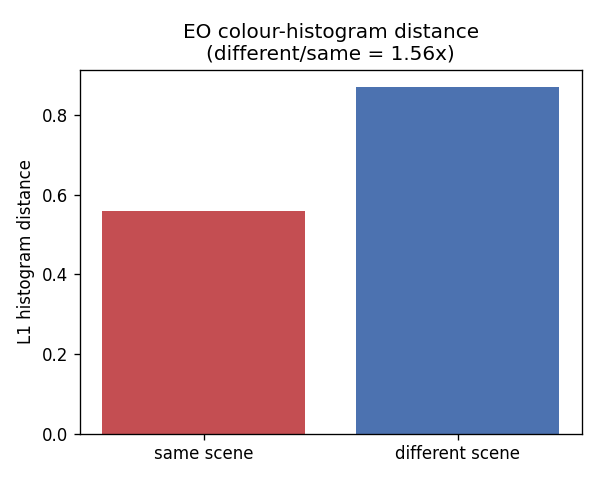

In [5]:
lk = STATS['leakage']
print(f"SAR  pixel MAD     same/diff scene: {lk['sar_intra_mean_abs_diff']:.1f} / {lk['sar_inter_mean_abs_diff']:.1f}  (ratio {lk['sar_ratio_inter_over_intra']:.2f}x)")
print(f"EO   colour-hist L1 same/diff scene: {lk['eo_intra_colorhist_dist']:.3f} / {lk['eo_inter_colorhist_dist']:.3f}  (ratio {lk['eo_ratio_inter_over_intra']:.2f}x)")
display(IPyImage('../outputs/eda/04_leakage.png'))

**Insight (measured, stated honestly).** On raw SAR the same-scene vs different-scene difference is only **1.16×** — weak, because multiplicative speckle dominates per-pixel differences. But on the **EO target**, patches from different scenes are **1.56× more dissimilar** in colour distribution than patches from the same scene. So the leakage is *distributional* (shared land-cover / colour / acquisition within a scene), not pixel-identical duplication. With only 32 scenes, a random 8:1:1 split puts patches from the **same scenes** in train and test — inflating reported metrics. The survey's Table 2 uses exactly this random protocol, so those numbers are an *optimistic* reference, not a generalisation estimate.

## 5. Split design: report both random and scene-disjoint

Given the above, we build two deterministic splits and will report metrics on both.

In [6]:
for strat in ['random', 'scene']:
    sp = build_splits(samples, strategy=strat, seed=42)
    print(f'\n=== {strat} split ===')
    for name in ['train','val','test']:
        from collections import Counter
        c = Counter(samples[i].terrain for i in sp[name])
        print(f'  {name:5s} n={len(sp[name]):6d}  ' + '  '.join(f'{k}:{v}' for k,v in sorted(c.items())))


=== random split ===
  train n= 12800  agri:3188  barrenland:3202  grassland:3243  urban:3167
  val   n=  1600  agri:398  barrenland:404  grassland:366  urban:432
  test  n=  1600  agri:414  barrenland:394  grassland:391  urban:401

=== scene split ===
  train n= 10454  agri:3056  barrenland:2010  grassland:2463  urban:2925
  val   n=  3469  agri:527  barrenland:1291  grassland:1088  urban:563
  test  n=  2077  agri:417  barrenland:699  grassland:449  urban:512


**Insight (measured).**
- **Split A — random 8:1:1** (12,800 / 1,600 / 1,600): reproduces the published protocol → directly comparable to survey Table 2 baselines (Pix2Pix LPIPS 0.483/FID 113.9, … E3-Diff 0.366/65.2).
- **Split B — scene-disjoint, terrain-stratified** (10,454 / 3,469 / 2,077): no scene appears in more than one split → an honest proxy for GalaxEye's private unseen-scene evaluation. Because there are only 32 coarse scenes and a few dominate, whole-scene allocation cannot hit 8:1:1 exactly (it lands ~65/21/13); we accept this as an unavoidable consequence of the data and keep every terrain present in every split for per-terrain analysis.
- **The A−B gap is itself a result we will report** — it measures how much of the random-split score is leakage rather than genuine SAR→EO skill.

## 6. Visual sanity check: SAR / EO pairs per terrain

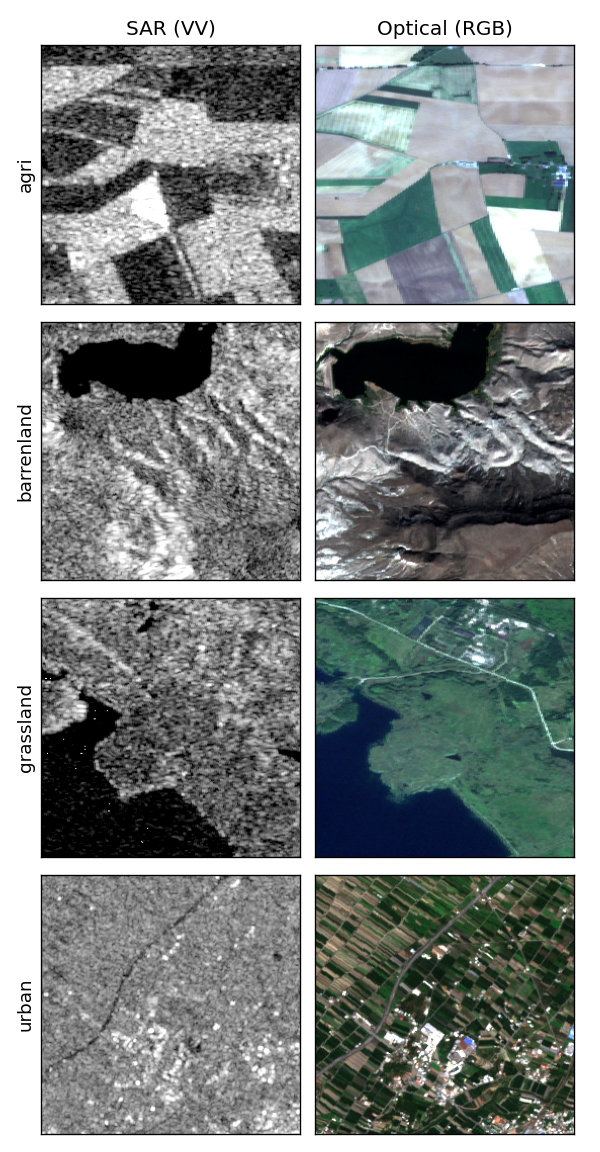

In [7]:
display(IPyImage('../outputs/eda/05_samples.png'))

**Insight (visual).** SAR conveys structure/texture (field boundaries, urban layout) but no colour; the paired EO shows the colour/material the model must infer. Urban scenes have the richest high-frequency texture (hardest to synthesise — we expect it to be the worst terrain, matching the survey's qualitative findings); agri/grassland are smoother and should translate more reliably.

## 7. EDA takeaways → design decisions

| Finding (measured) | Decision |
|---|---|
| Only 32 scenes for 16,000 patches; EO colour-hist 1.56× more distinct across scenes | Report **both** random (comparable) and scene-disjoint (honest) splits |
| SAR↔optical luminance corr ≈ -0.04 (one-to-many map) | Rank on **LPIPS/FID**; use adversarial+perceptual loss, not pixel-only |
| Speckle CoV ~0.20–0.28 (inherent multiplicative noise) | Don't despeckle; let the model learn through speckle |
| SAR already dB-scaled [0,255] = inference contract format | Train on native SAR → no train/infer mismatch; both modalities → [−1,1] |
| Seasons: only agri has summer; barrenland, grassland, urban are 100% fall | Flag limited seasonal diversity as a generalisation risk; motivates adding SEN12MS later |
| Urban brightest SAR (mean 157.0), richest texture | Expect urban = hardest terrain; analyse per-terrain error profile |
